# Brazilian E-Commerce Analytics with SQL

This project analyzes the Brazilian Olist e-commerce dataset to understand business performance, customer experience, delivery behavior, payments, sellers, and product performance.

The project was completed using Python, SQL, SQLite, Pandas, Google Colab, and data visualization.

# 2. Business Understanding

Olist is a Brazilian e-commerce marketplace that connects customers, sellers, products, payments, delivery operations, and customer reviews.

The purpose of this project is to answer key business questions such as:

- How are orders and revenue changing over time?
- Which products and sellers perform best?
- How does delivery performance affect customer satisfaction?
- What payment and customer behavior patterns can be identified?
- Where are logistics and freight costs relatively high?

# 3. Dataset Overview

The dataset was obtained from Kaggle and contains 9 CSV files covering the complete e-commerce order lifecycle.

Main data areas include:

- Customers
- Orders
- Order Items
- Payments
- Reviews
- Products
- Sellers
- Geolocation
- Product Category Translation

The data contains more than 99,000 orders and over 100,000 order-item and payment records.

# 4. Tools and Workflow

The project was developed using:

- Google Colab
- Google Drive
- Python
- Pandas
- SQLite
- SQL
- Matplotlib

The CSV files were stored in Google Drive and loaded into a SQLite database using Pandas.

SQL was used for data analysis, aggregation, joins, ranking, and business metrics, while Python was used to manage the database connection and create visualizations.

# 5. Analysis Approach

Before starting the analysis, the data was reviewed to understand:

- Table structure
- Primary and joining keys
- Duplicate records
- Missing values
- Table grain
- Relationships between tables

The analysis was then divided into 12 business tasks covering revenue, customer experience, sellers, payments, delivery performance, repeat customers, freight efficiency, and reusable analytical views.

Visualizations were also created to make trends and business insights easier to interpret.

# Project Setup — Rewan Ebrahem

This is the common setup used by all 12 tasks.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sqlite3
import pandas as pd

In [ ]:
BASE_PATH = "/content/drive/MyDrive/SQL_Capstone_Group1_Rewan"
DATA_PATH = f"{BASE_PATH}/data"
DB_PATH = f"{BASE_PATH}/olist.db"

In [ ]:
os.makedirs(DATA_PATH, exist_ok=True)

In [ ]:
conn = sqlite3.connect(DB_PATH)

print("Connected successfully")
print(DB_PATH)

Connected successfully
/content/drive/MyDrive/SQL_Capstone_Group1_Rewan/olist.db


In [ ]:
tables = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv"
}

In [ ]:
for table_name, file_name in tables.items():

    table_exists = conn.execute(
        """
        SELECT name
        FROM sqlite_master
        WHERE type='table' AND name=?
        """,
        (table_name,)
    ).fetchone()

    if table_exists:
        print(f"{table_name} already exists - skipped")

    else:
        file_path = f"{DATA_PATH}/{file_name}"

        df = pd.read_csv(file_path)

        df.to_sql(
            table_name,
            conn,
            if_exists="fail",
            index=False
        )

        print(f"{table_name}: {len(df):,} rows loaded")

customers already exists - skipped
geolocation already exists - skipped
order_items already exists - skipped
order_payments already exists - skipped
order_reviews already exists - skipped
orders already exists - skipped
products already exists - skipped
sellers already exists - skipped
category_translation already exists - skipped


In [ ]:
query = """
SELECT
    name AS table_name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
"""

pd.read_sql_query(query, conn)

,table_name
0,category_translation
1,customers
2,geolocation
3,order_items
4,order_payments
5,order_reviews
6,orders
7,products
8,sellers


In [ ]:
for table_name in tables.keys():

    count = pd.read_sql_query(
        f"SELECT COUNT(*) AS row_count FROM {table_name}",
        conn
    )

    print(
        table_name,
        "→",
        f"{count.loc[0, 'row_count']:,}",
        "rows"
    )

customers → 99,441 rows
geolocation → 1,000,163 rows
order_items → 112,650 rows
order_payments → 103,886 rows
order_reviews → 99,224 rows
orders → 99,441 rows
products → 32,951 rows
sellers → 3,095 rows
category_translation → 71 rows


In [ ]:
for table_name in [
    "orders",
    "order_items",
    "order_payments",
    "order_reviews",
    "products"
]:
    print(f"\n===== {table_name} =====")

    df = pd.read_sql_query(
        f"SELECT * FROM {table_name} LIMIT 5",
        conn
    )

    display(df)


===== orders =====


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



===== order_items =====


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



===== order_payments =====


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



===== order_reviews =====


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,None,None,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,None,None,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,None,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,None,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



===== products =====


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
key_checks = {
    "orders": "order_id",
    "order_items": "order_id",
    "order_payments": "order_id",
    "order_reviews": "order_id",
    "products": "product_id"
}

for table_name, key_column in key_checks.items():

    query = f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT {key_column}) AS distinct_keys,
        COUNT(*) - COUNT(DISTINCT {key_column}) AS duplicate_key_rows
    FROM {table_name};
    """

    result = pd.read_sql_query(query, conn)

    print(f"\n===== {table_name} =====")
    display(result)


===== orders =====


,total_rows,distinct_keys,duplicate_key_rows
0,99441,99441,0



===== order_items =====


,total_rows,distinct_keys,duplicate_key_rows
0,112650,98666,13984



===== order_payments =====


,total_rows,distinct_keys,duplicate_key_rows
0,103886,99440,4446



===== order_reviews =====


,total_rows,distinct_keys,duplicate_key_rows
0,99224,98673,551



===== products =====


,total_rows,distinct_keys,duplicate_key_rows
0,32951,32951,0


In [ ]:
queries = {
    "order_items": """
        SELECT
            order_id,
            COUNT(*) AS rows_per_order
        FROM order_items
        GROUP BY order_id
        ORDER BY rows_per_order DESC
        LIMIT 10;
    """,

    "order_payments": """
        SELECT
            order_id,
            COUNT(*) AS rows_per_order
        FROM order_payments
        GROUP BY order_id
        ORDER BY rows_per_order DESC
        LIMIT 10;
    """,

    "order_reviews": """
        SELECT
            order_id,
            COUNT(*) AS rows_per_order
        FROM order_reviews
        GROUP BY order_id
        ORDER BY rows_per_order DESC
        LIMIT 10;
    """
}

for name, query in queries.items():
    print(f"\n===== {name} =====")
    display(pd.read_sql_query(query, conn))


===== order_items =====


,order_id,rows_per_order
0,8272b63d03f5f79c56e9e4120aec44ef,21
1,ab14fdcfbe524636d65ee38360e22ce8,20
2,1b15974a0141d54e36626dca3fdc731a,20
3,9ef13efd6949e4573a18964dd1bbe7f5,15
4,428a2f660dc84138d969ccd69a0ab6d5,15
5,9bdc4d4c71aa1de4606060929dee888c,14
6,73c8ab38f07dc94389065f7eba4f297a,14
7,37ee401157a3a0b28c9c6d0ed8c3b24b,13
8,c05d6a79e55da72ca780ce90364abed9,12
9,af822dacd6f5cff7376413c03a388bb7,12



===== order_payments =====


,order_id,rows_per_order
0,fa65dad1b0e818e3ccc5cb0e39231352,29
1,ccf804e764ed5650cd8759557269dc13,26
2,285c2e15bebd4ac83635ccc563dc71f4,22
3,895ab968e7bb0d5659d16cd74cd1650c,21
4,fedcd9f7ccdc8cba3a18defedd1a5547,19
5,ee9ca989fc93ba09a6eddc250ce01742,19
6,4bfcba9e084f46c8e3cb49b0fa6e6159,15
7,21577126c19bf11a0b91592e5844ba78,15
8,4689b1816de42507a7d63a4617383c59,14
9,3c58bffb70dcf45f12bdf66a3c215905,14



===== order_reviews =====


,order_id,rows_per_order
0,df56136b8031ecd28e200bb18e6ddb2e,3
1,c88b1d1b157a9999ce368f218a407141,3
2,8e17072ec97ce29f0e1f111e598b0c85,3
3,03c939fd7fd3b38f8485a0f95798f1f6,3
4,ffaabba06c9d293a3c614e0515ddbabc,2
5,ff850ba359507b996e8b2fbb26df8d03,2
6,ff763b73e473d03c321bcd5a053316e8,2
7,fe041ba1c9f54016432fa6ee91709dbc,2
8,fd95ae805c63c534f1a64589e102225e,2
9,fd61441ba2a7b57e6342862e779b10b0,2


# Task 1 — Data Quality and Key Audit — Owner: Leqaa


Orders Table

In [ ]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS unique_orders,
    SUM(CASE WHEN order_id IS NULL THEN 1 ELSE 0 END) AS null_orders,
    SUM(CASE WHEN order_id IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS null_order_rate
FROM orders;
"""

pd.read_sql_query(query, conn)


,total_rows,unique_orders,null_orders,null_order_rate
0,99441,99441,0,0.0


Check duplicate values

In [ ]:
query = """
SELECT
    order_id,
    COUNT(*) AS order_count
FROM orders
WHERE order_id IS NOT NULL
GROUP BY order_id
HAVING COUNT(*) > 1;
"""

pd.read_sql_query(query, conn)


,order_id,order_count


Grain: One row represents one order.

Order Items Table

In [ ]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS unique_orders,
    SUM(CASE WHEN order_id IS NULL THEN 1 ELSE 0 END) AS null_orders,
    SUM(CASE WHEN order_id IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS null_order_rate,
    SUM(CASE WHEN order_item_id IS NULL THEN 1 ELSE 0 END) AS null_items,
    SUM(CASE WHEN order_item_id IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS null_item_rate
FROM order_items;
"""

pd.read_sql_query(query, conn)


,total_rows,unique_orders,null_orders,null_order_rate,null_items,null_item_rate
0,112650,98666,0,0.0,0,0.0


Check duplicate values

In [ ]:
query = """
SELECT
    order_id,
    order_item_id,
    COUNT(*) AS item_count
FROM order_items
WHERE order_id IS NOT NULL
  AND order_item_id IS NOT NULL
GROUP BY order_id, order_item_id
HAVING COUNT(*) > 1;
"""

pd.read_sql_query(query, conn)


,order_id,order_item_id,item_count


Grain:One row represents one item within an order.

Order Payments Table

In [ ]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS unique_orders,
    SUM(CASE WHEN order_id IS NULL THEN 1 ELSE 0 END) AS null_orders,
    SUM(CASE WHEN order_id IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS null_order_rate,
    SUM(CASE WHEN payment_sequential IS NULL THEN 1 ELSE 0 END) AS null_payments,
    SUM(CASE WHEN payment_sequential IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS null_payment_rate
FROM order_payments;
"""

pd.read_sql_query(query, conn)


,total_rows,unique_orders,null_orders,null_order_rate,null_payments,null_payment_rate
0,103886,99440,0,0.0,0,0.0


Check duplicate values

In [ ]:
query = """
SELECT
    order_id,
    payment_sequential,
    COUNT(*) AS payment_count
FROM order_payments
WHERE order_id IS NOT NULL
  AND payment_sequential IS NOT NULL
GROUP BY order_id, payment_sequential
HAVING COUNT(*) > 1;
"""

pd.read_sql_query(query, conn)


,order_id,payment_sequential,payment_count


Grain: One row represents one payment record for an order.

Customers Table

In [ ]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT customer_id) AS unique_customers,
    SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) AS null_customers,
    SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS null_customer_rate
FROM customers;
"""

pd.read_sql_query(query, conn)


,total_rows,unique_customers,null_customers,null_customer_rate
0,99441,99441,0,0.0


Check duplicate values

In [ ]:
query = """
SELECT
    customer_id,
    COUNT(*) AS customer_count
FROM customers
WHERE customer_id IS NOT NULL
GROUP BY customer_id
HAVING COUNT(*) > 1;
"""

pd.read_sql_query(query, conn)


,customer_id,customer_count


Grain: One row represents one customer.

Products Table

In [ ]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT product_id) AS unique_products,
    SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) AS null_products,
    SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS null_product_rate
FROM products;
"""

pd.read_sql_query(query, conn)


,total_rows,unique_products,null_products,null_product_rate
0,32951,32951,0,0.0


Check duplicate values

In [ ]:
query = """
SELECT
    product_id,
    COUNT(*) AS product_count
FROM products
WHERE product_id IS NOT NULL
GROUP BY product_id
HAVING COUNT(*) > 1;
"""

pd.read_sql_query(query, conn)


,product_id,product_count


Grain: One row represents one product.

Sellers Table

In [ ]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT seller_id) AS unique_sellers,
    SUM(CASE WHEN seller_id IS NULL THEN 1 ELSE 0 END) AS null_sellers,
    SUM(CASE WHEN seller_id IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS null_seller_rate
FROM sellers;
"""

pd.read_sql_query(query, conn)


,total_rows,unique_sellers,null_sellers,null_seller_rate
0,3095,3095,0,0.0


Check duplicate values

In [ ]:
query = """
SELECT
    seller_id,
    COUNT(*) AS seller_count
FROM sellers
WHERE seller_id IS NOT NULL
GROUP BY seller_id
HAVING COUNT(*) > 1;
"""

pd.read_sql_query(query, conn)


,seller_id,seller_count


Grain: One row represents one seller.

Order Reviews Table

In [ ]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT review_id) AS unique_reviews,
    SUM(CASE WHEN review_id IS NULL THEN 1 ELSE 0 END) AS null_reviews,
    SUM(CASE WHEN review_id IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS null_review_rate
FROM order_reviews;
"""

pd.read_sql_query(query, conn)


,total_rows,unique_reviews,null_reviews,null_review_rate
0,99224,98410,0,0.0


Check duplicate values

In [ ]:
query = """
SELECT
    review_id,
    COUNT(*) AS review_count
FROM order_reviews
WHERE review_id IS NOT NULL
GROUP BY review_id
HAVING COUNT(*) > 1;
"""

pd.read_sql_query(query, conn)


,review_id,review_count
0,00130cbe1f9d422698c812ed8ded1919,2
1,0115633a9c298b6a98bcbe4eee75345f,2
2,0174caf0ee5964646040cd94e15ac95e,2
3,017808d29fd1f942d97e50184dfb4c13,2
4,0254bd905dc677a6078990aad3331a36,2
...,...,...
784,fde2e6abaf5bb64f7407a44741c24dec,2
785,fde5986d35c89aa1b6ce4149de82a0d3,2
786,fe5c833752953fed3209646f1f63b53c,2
787,ff2fc9e68f8aabfbe18d710b83aabd30,2


Grain: One row represents one review record.

Category Translation Table

In [ ]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT product_category_name) AS unique_categories,
    SUM(CASE WHEN product_category_name IS NULL THEN 1 ELSE 0 END) AS null_categories,
    SUM(CASE WHEN product_category_name IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS null_category_rate
FROM category_translation;
"""

pd.read_sql_query(query, conn)


,total_rows,unique_categories,null_categories,null_category_rate
0,71,71,0,0.0


Check duplicate values

In [ ]:
query = """
SELECT
    product_category_name,
    COUNT(*) AS category_count
FROM category_translation
WHERE product_category_name IS NOT NULL
GROUP BY product_category_name
HAVING COUNT(*) > 1;
"""

pd.read_sql_query(query, conn)


,product_category_name,category_count


Grain: One row represents one product category translation.

# Task 2 — Executive KPI Layer — Owner:  Rewan Mousa


In [ ]:
task2 = pd.read_sql_query("""
SELECT
    (SELECT COUNT(DISTINCT order_id)
     FROM orders) AS total_orders,

    (SELECT COUNT(DISTINCT order_id)
     FROM orders
     WHERE order_status = 'delivered') AS delivered_orders,

    (SELECT COUNT(DISTINCT order_id)
     FROM orders
     WHERE order_status = 'canceled') AS canceled_orders,

    (SELECT SUM(price)
     FROM order_items) AS gross_item_revenue,

    (SELECT SUM(freight_value)
     FROM order_items) AS total_freight,

    (SELECT SUM(payment_value)
     FROM order_payments) AS total_payment_value,

    ROUND(
        (SELECT SUM(payment_value)
         FROM order_payments) * 1.0
        /
        (SELECT COUNT(DISTINCT order_id)
         FROM orders),
        2
    ) AS average_order_value,

    ROUND(
        (SELECT COUNT(*)
         FROM order_items) * 1.0
        /
        (SELECT COUNT(DISTINCT order_id)
         FROM orders),
        2
    ) AS average_items_per_order
""", conn)

task2


,total_orders,delivered_orders,canceled_orders,gross_item_revenue,total_freight,total_payment_value,average_order_value,average_items_per_order
0,99441,96478,625,13591643.7,2251909.54,16008872.12,160.99,1.13


# Task 3 — Monthly Business Trend — Owner:Rewan Ebrahem


In [ ]:
query_task3_order_level = """
WITH payment_per_order AS (
    SELECT
        order_id,
        SUM(payment_value) AS order_revenue
    FROM order_payments
    GROUP BY order_id
)

SELECT
    o.order_id,
    o.order_purchase_timestamp,
    p.order_revenue
FROM orders AS o
LEFT JOIN payment_per_order AS p
    ON o.order_id = p.order_id
LIMIT 10;
"""

pd.read_sql_query(query_task3_order_level, conn)

,order_id,order_purchase_timestamp,order_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,28.62
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,175.26
6,136cce7faa42fdb2cefd53fdc79a6098,2017-04-11 12:22:08,65.95
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,75.16
8,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,35.95
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,169.76


In [ ]:
query_task3_monthly = """
WITH payment_per_order AS (
    SELECT
        order_id,
        SUM(payment_value) AS order_revenue
    FROM order_payments
    GROUP BY order_id
)

SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,

    COUNT(o.order_id) AS total_orders,

    ROUND(
        SUM(p.order_revenue),
        2
    ) AS total_revenue,

    ROUND(
        AVG(p.order_revenue),
        2
    ) AS avg_order_value

FROM orders AS o
LEFT JOIN payment_per_order AS p
    ON o.order_id = p.order_id

GROUP BY
    strftime('%Y-%m', o.order_purchase_timestamp)

ORDER BY
    month;
"""

monthly_trend = pd.read_sql_query(
    query_task3_monthly,
    conn
)

display(monthly_trend)

,month,total_orders,total_revenue,avg_order_value
0,2016-09,4,252.24,84.08
1,2016-10,324,59090.48,182.38
2,2016-12,1,19.62,19.62
3,2017-01,800,138488.04,173.11
4,2017-02,1780,291908.01,163.99
5,2017-03,2682,449863.60,167.73
6,2017-04,2404,417788.03,173.79
7,2017-05,3700,592918.82,160.25
8,2017-06,3245,511276.38,157.56
9,2017-07,4026,592382.92,147.14


In [ ]:
monthly_trend_analysis = monthly_trend.copy()

monthly_trend_analysis["order_growth_pct"] = (
    monthly_trend_analysis["total_orders"]
    .pct_change() * 100
)

monthly_trend_analysis["revenue_growth_pct"] = (
    monthly_trend_analysis["total_revenue"]
    .pct_change() * 100
)

monthly_trend_analysis["aov_growth_pct"] = (
    monthly_trend_analysis["avg_order_value"]
    .pct_change() * 100
)

monthly_trend_analysis = monthly_trend_analysis.round(2)

display(monthly_trend_analysis)

,month,total_orders,total_revenue,avg_order_value,order_growth_pct,revenue_growth_pct,aov_growth_pct
0,2016-09,4,252.24,84.08,NaN,NaN,NaN
1,2016-10,324,59090.48,182.38,8000.00,23326.29,116.91
2,2016-12,1,19.62,19.62,-99.69,-99.97,-89.24
3,2017-01,800,138488.04,173.11,79900.00,705751.38,782.31
4,2017-02,1780,291908.01,163.99,122.50,110.78,-5.27
5,2017-03,2682,449863.60,167.73,50.67,54.11,2.28
6,2017-04,2404,417788.03,173.79,-10.37,-7.13,3.61
7,2017-05,3700,592918.82,160.25,53.91,41.92,-7.79
8,2017-06,3245,511276.38,157.56,-12.30,-13.77,-1.68
9,2017-07,4026,592382.92,147.14,24.07,15.86,-6.61


In [ ]:
def classify_trend(value):
    if pd.isna(value):
        return "No Previous Month"
    elif value > 0:
        return "Growth"
    elif value < 0:
        return "Decline"
    else:
        return "Stable"

monthly_trend_analysis["revenue_trend"] = (
    monthly_trend_analysis["revenue_growth_pct"]
    .apply(classify_trend)
)

display(
    monthly_trend_analysis[
        [
            "month",
            "total_orders",
            "total_revenue",
            "avg_order_value",
            "revenue_growth_pct",
            "revenue_trend"
        ]
    ]
)

,month,total_orders,total_revenue,avg_order_value,revenue_growth_pct,revenue_trend
0,2016-09,4,252.24,84.08,NaN,No Previous Month
1,2016-10,324,59090.48,182.38,23326.29,Growth
2,2016-12,1,19.62,19.62,-99.97,Decline
3,2017-01,800,138488.04,173.11,705751.38,Growth
4,2017-02,1780,291908.01,163.99,110.78,Growth
5,2017-03,2682,449863.60,167.73,54.11,Growth
6,2017-04,2404,417788.03,173.79,-7.13,Decline
7,2017-05,3700,592918.82,160.25,41.92,Growth
8,2017-06,3245,511276.38,157.56,-13.77,Decline
9,2017-07,4026,592382.92,147.14,15.86,Growth


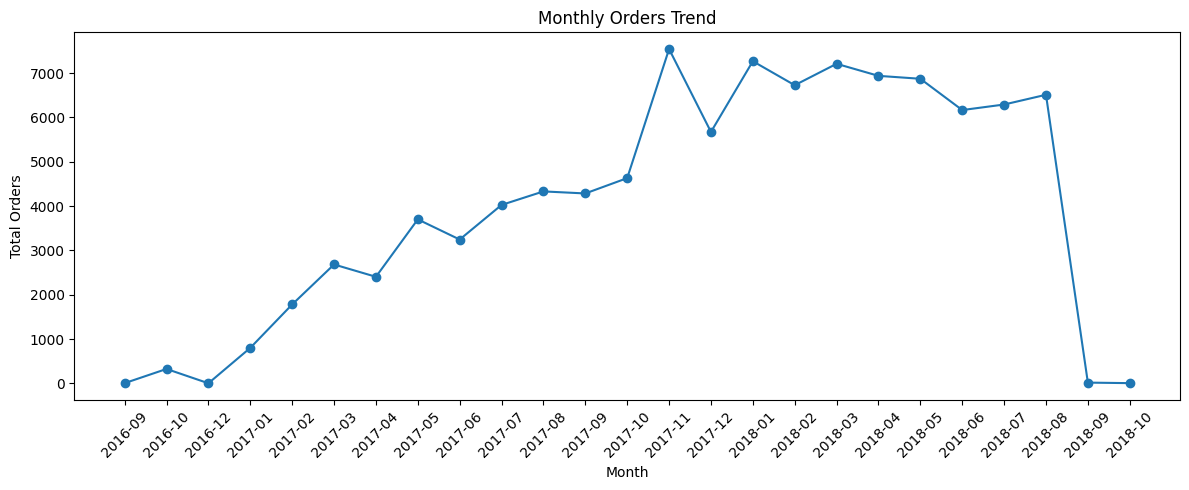

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_trend_analysis["month"],
    monthly_trend_analysis["total_orders"],
    marker="o"
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

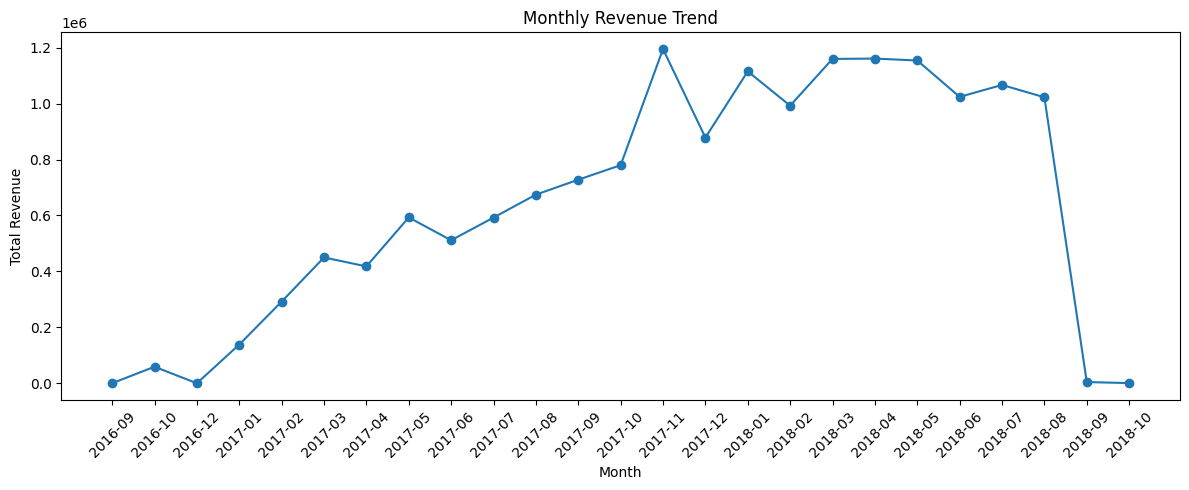

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_trend_analysis["month"],
    monthly_trend_analysis["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

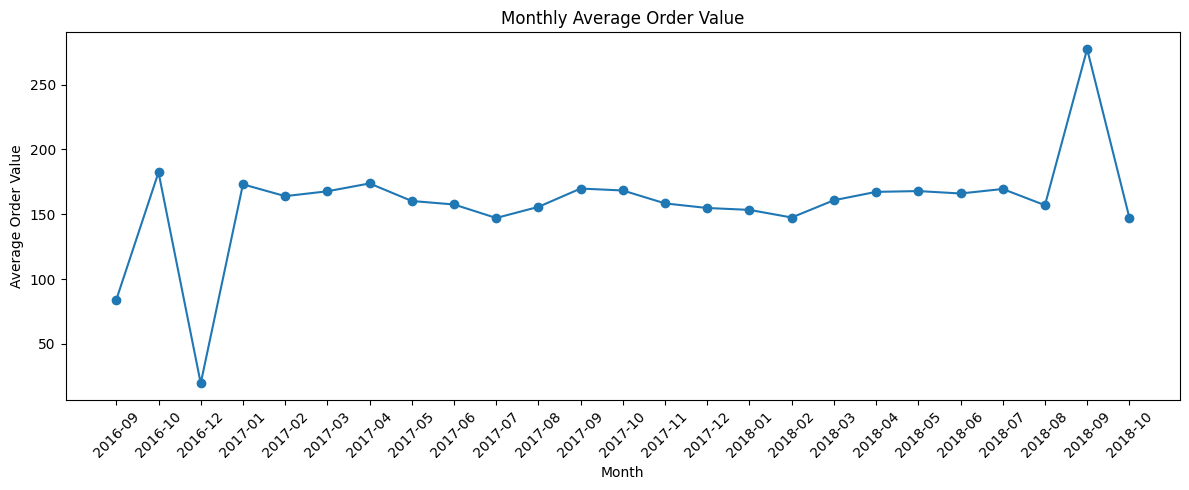

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_trend_analysis["month"],
    monthly_trend_analysis["avg_order_value"],
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Task 4 — Category Performance — Owner: Ibraheem


In [ ]:
query = """
SELECT
    p.product_category_name AS category,
    COUNT(DISTINCT oi.order_id) AS order_count
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY order_count DESC;
"""

result = pd.read_sql_query(query, conn)
result.head(20)


,category,order_count
0,cama_mesa_banho,9417
1,beleza_saude,8836
2,esporte_lazer,7720
3,informatica_acessorios,6689
4,moveis_decoracao,6449
5,utilidades_domesticas,5884
6,relogios_presentes,5624
7,telefonia,4199
8,automotivo,3897
9,brinquedos,3886


In [ ]:
query = """
SELECT
    p.product_category_name AS category,
    COUNT(*) AS units_sold
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY units_sold DESC;
"""

result = pd.read_sql_query(query, conn)
result.head(20)


,category,units_sold
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


In [ ]:
query = """
SELECT
    p.product_category_name AS category,
    ROUND(SUM(oi.price), 2) AS total_revenue
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY total_revenue DESC;
"""

result = pd.read_sql_query(query, conn)
result.head(20)


,category,total_revenue
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


In [ ]:
query_task_4 = """
SELECT
    COALESCE(t.product_category_name_english, p.product_category_name) AS category_name,
    COUNT(DISTINCT oi.order_id) AS total_orders,
    COUNT(oi.order_item_id) AS total_units_sold,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    ROUND(AVG(oi.price), 2) AS average_price,
    ROUND(AVG(oi.freight_value), 2) AS average_freight
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation t ON p.product_category_name = t.product_category_name
GROUP BY category_name
HAVING COUNT(DISTINCT oi.order_id) >= 50
ORDER BY total_revenue DESC;
"""

df_category_performance = pd.read_sql_query(query_task_4, conn)
df_category_performance.head(10)


,category_name,total_orders,total_units_sold,total_revenue,average_price,average_freight
0,health_beauty,8836,9670,1258681.34,130.16,18.88
1,watches_gifts,5624,5991,1205005.68,201.14,16.78
2,bed_bath_table,9417,11115,1036988.68,93.30,18.42
3,sports_leisure,7720,8641,988048.97,114.34,19.51
4,computers_accessories,6689,7827,911954.32,116.51,18.82
5,furniture_decor,6449,8334,729762.49,87.56,20.73
6,cool_stuff,3632,3796,635290.85,167.36,22.14
7,housewares,5884,6964,632248.66,90.79,20.99
8,auto,3897,4235,592720.11,139.96,21.88
9,garden_tools,3518,4347,485256.46,111.63,22.77


/tmp/ipykernel_606/1264141654.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


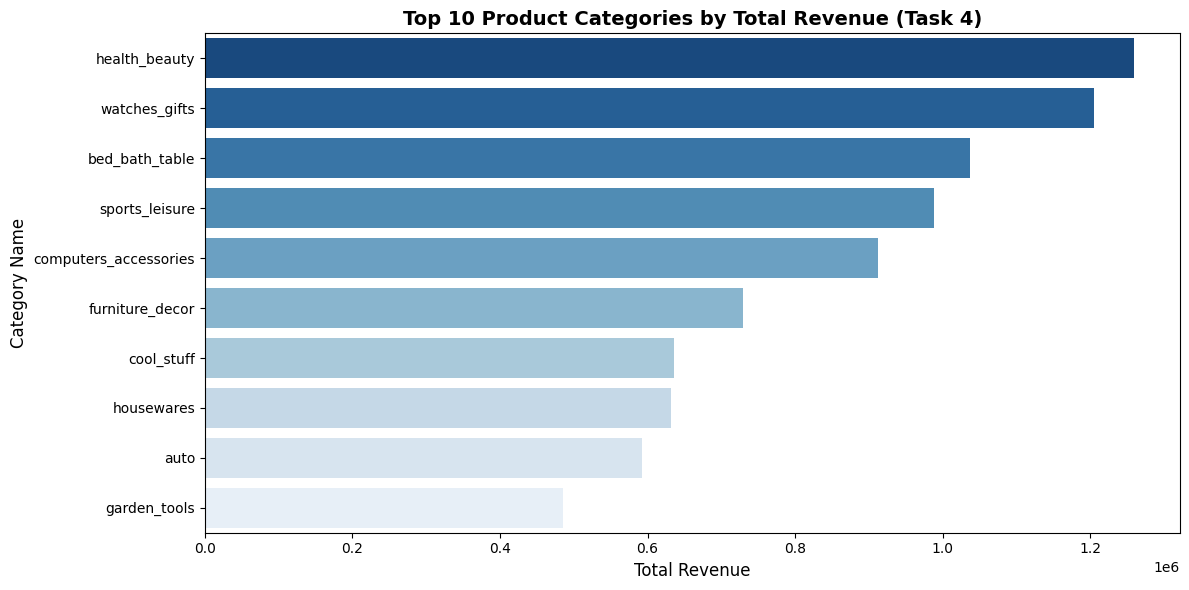

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# رسم أعلى 10 فئات من حيث الإيرادات (Task 4)
plt.figure(figsize=(12, 6))
top_10_cats = df_category_performance.head(10)

sns.barplot(
    data=top_10_cats,
    x='total_revenue',
    y='category_name',
    palette='Blues_r'
)

plt.title('Top 10 Product Categories by Total Revenue (Task 4)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Category Name', fontsize=12)
plt.tight_layout()
plt.show()


# Task 5 — Payment Behavior — Owner: Ibraheem


In [ ]:
# Task 5: تحليل سلوك طرق الدفع وقيمتها وعدد الأقساط
query_task_5 = """
SELECT
    payment_type,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(payment_value), 2) AS total_payment_value,
    ROUND(AVG(payment_value), 2) AS average_order_value,
    ROUND(AVG(payment_installments), 1) AS avg_installments
FROM order_payments
GROUP BY payment_type
ORDER BY total_payment_value DESC;
"""

df_payment_behavior = pd.read_sql_query(query_task_5, conn)
df_payment_behavior


,payment_type,total_orders,total_payment_value,average_order_value,avg_installments
0,credit_card,76505,12542084.19,163.32,3.5
1,boleto,19784,2869361.27,145.03,1.0
2,voucher,3866,379436.87,65.70,1.0
3,debit_card,1528,217989.79,142.57,1.0
4,not_defined,3,0.00,0.00,1.0


# Task 6 — Seller Performance — Owner: leqaa


1. Seller Sales

orders + revenue + freight.

In [ ]:
query = """
SELECT
    seller_id,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(price) AS item_revenue,
    SUM(freight_value) AS total_freight
FROM order_items
GROUP BY seller_id
HAVING COUNT(DISTINCT order_id) >= 10
ORDER BY total_orders DESC;
"""

pd.read_sql_query(query, conn)


,seller_id,total_orders,item_revenue,total_freight
0,6560211a19b47992c3666cc44a7e94c0,1854,123304.83,27960.94
1,4a3ca9315b744ce9f8e9374361493884,1806,200472.92,35067.04
2,cc419e0650a3c5ba77189a1882b7556a,1706,104288.42,25668.99
3,1f50f920176fa81dab994f9023523100,1404,106939.21,35165.77
4,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57,24955.75
...,...,...,...,...
1266,1e483cc5c76fef08d3ca05f9a8af7d01,10,171.99,123.08
1267,1996942dc085d7773ba77a529b163cd0,10,2943.51,239.92
1268,0ff83046c3fa22efee8ecf291888b191,10,768.90,254.48
1269,05a940b4ecae36cadfd8e93bd9c43257,10,952.00,196.94


2. Unique Customers

In [ ]:
query = """
SELECT
    oi.seller_id,
    COUNT(DISTINCT o.customer_id) AS unique_customers
FROM order_items oi
JOIN orders o
    ON oi.order_id = o.order_id
GROUP BY oi.seller_id;
"""

pd.read_sql_query(query, conn)


,seller_id,unique_customers
0,0015a82c2db000af6aaaf3ae2ecb0532,3
1,001cca7ae9ae17fb1caed9dfb1094831,200
2,001e6ad469a905060d959994f1b41e4f,1
3,002100f778ceb8431b7a1020ff7ab48f,51
4,003554e2dce176b5555353e4f3555ac8,1
...,...,...
3090,ffcfefa19b08742c5d315f2791395ee5,1
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,18
3092,ffeee66ac5d5a62fe688b9d26f83f534,14
3093,fffd5413c0700ac820c7069d66d98c89,60


3. Average Review Score

In [ ]:
query = """
SELECT
    oi.seller_id,
    AVG(r.review_score) AS average_review_score
FROM (
    SELECT DISTINCT seller_id, order_id
    FROM order_items
) oi
JOIN order_reviews r
    ON oi.order_id = r.order_id
GROUP BY oi.seller_id;
"""

pd.read_sql_query(query, conn)


,seller_id,average_review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,3.984772
2,001e6ad469a905060d959994f1b41e4f,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,3.903846
4,003554e2dce176b5555353e4f3555ac8,5.000000
...,...,...
3085,ffcfefa19b08742c5d315f2791395ee5,1.000000
3086,ffdd9f82b9a447f6f8d4b91554cc7dd3,4.333333
3087,ffeee66ac5d5a62fe688b9d26f83f534,4.214286
3088,fffd5413c0700ac820c7069d66d98c89,3.847458


4. Late Delivery Rate

In [ ]:
query = """
SELECT
    oi.seller_id,
    AVG(
        CASE
            WHEN o.order_delivered_customer_date IS NOT NULL
             AND o.order_estimated_delivery_date IS NOT NULL
            THEN
                CASE
                    WHEN o.order_delivered_customer_date >
                         o.order_estimated_delivery_date
                    THEN 1.0
                    ELSE 0.0
                END
        END
    ) * 100 AS late_delivery_rate
FROM (
    SELECT DISTINCT seller_id, order_id
    FROM order_items
) oi
JOIN orders o
    ON oi.order_id = o.order_id
GROUP BY oi.seller_id;
"""

pd.read_sql_query(query, conn)


,seller_id,late_delivery_rate
0,0015a82c2db000af6aaaf3ae2ecb0532,0.000000
1,001cca7ae9ae17fb1caed9dfb1094831,6.666667
2,001e6ad469a905060d959994f1b41e4f,NaN
3,002100f778ceb8431b7a1020ff7ab48f,18.000000
4,003554e2dce176b5555353e4f3555ac8,0.000000
...,...,...
3090,ffcfefa19b08742c5d315f2791395ee5,NaN
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,0.000000
3092,ffeee66ac5d5a62fe688b9d26f83f534,14.285714
3093,fffd5413c0700ac820c7069d66d98c89,14.035088


5. Final Seller Performance Table

In [ ]:
query = """
WITH seller_sales AS (
    SELECT
        seller_id,
        COUNT(DISTINCT order_id) AS total_orders,
        SUM(price) AS item_revenue,
        SUM(freight_value) AS total_freight
    FROM order_items
    GROUP BY seller_id
    HAVING COUNT(DISTINCT order_id) >= 10
),

seller_customers AS (
    SELECT
        oi.seller_id,
        COUNT(DISTINCT o.customer_id) AS unique_customers
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    GROUP BY oi.seller_id
),

seller_reviews AS (
    SELECT
        oi.seller_id,
        AVG(r.review_score) AS average_review_score
    FROM (
        SELECT DISTINCT seller_id, order_id
        FROM order_items
    ) oi
    JOIN order_reviews r
        ON oi.order_id = r.order_id
    GROUP BY oi.seller_id
),

seller_delivery AS (
    SELECT
        oi.seller_id,
        AVG(
            CASE
                WHEN o.order_delivered_customer_date IS NOT NULL
                 AND o.order_estimated_delivery_date IS NOT NULL
                THEN
                    CASE
                        WHEN o.order_delivered_customer_date >
                             o.order_estimated_delivery_date
                        THEN 1.0
                        ELSE 0.0
                    END
            END
        ) * 100 AS late_delivery_rate
    FROM (
        SELECT DISTINCT seller_id, order_id
        FROM order_items
    ) oi
    JOIN orders o
        ON oi.order_id = o.order_id
    GROUP BY oi.seller_id
)

SELECT
    s.seller_id,
    s.total_orders,
    c.unique_customers,
    s.item_revenue,
    s.total_freight,
    r.average_review_score,
    d.late_delivery_rate
FROM seller_sales s
LEFT JOIN seller_customers c
    ON s.seller_id = c.seller_id
LEFT JOIN seller_reviews r
    ON s.seller_id = r.seller_id
LEFT JOIN seller_delivery d
    ON s.seller_id = d.seller_id
ORDER BY s.total_orders DESC;
"""

seller_df = pd.read_sql_query(query, conn)
seller_df

top_sellers = seller_df.sort_values("item_revenue", ascending=False).head(10)

top_sellers


,seller_id,total_orders,unique_customers,item_revenue,total_freight,average_review_score,late_delivery_rate
8,4869f7a5dfa277a7dca6462dcf3b52b2,1132,1132,229472.63,20168.07,4.133452,11.565836
39,53243585a1d6dc2643021fd1853d8905,358,358,222776.05,13080.63,4.132022,4.310345
1,4a3ca9315b744ce9f8e9374361493884,1806,1806,200472.92,35067.04,3.827873,11.004515
18,fa1c13f2614d7b5c4749cbc52fecda94,585,585,194042.03,10042.70,4.339071,10.207612
10,7c67e1448b00f6e969d365cea6b010ab,982,982,187923.89,51612.55,3.488798,10.071942
45,7e93a43ef30c4f03f38b393420bc753a,336,336,176431.87,6322.18,4.214925,5.642633
4,da8622b14eb17ae2831f4ac5b9dab84a,1314,1314,160236.57,24955.75,4.178868,7.627765
6,7a67c85e85bb2ce8582c35f2203ad736,1160,1160,141745.53,20902.85,4.244156,5.938865
12,1025f0e2d44d7041d6cf58b6550e0bfa,915,915,138968.55,33892.14,3.989059,10.109890
5,955fee9216a65b617aa5c0531780ce60,1287,1287,135171.70,25430.98,4.158718,7.771610


📊 Seller Performance — Item Revenue

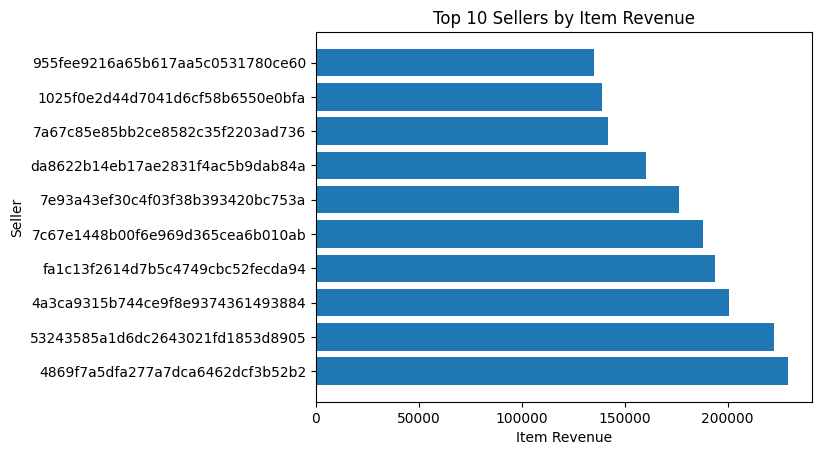

In [ ]:
import matplotlib.pyplot as plt

plt.barh(top_sellers["seller_id"], top_sellers["item_revenue"])

plt.xlabel("Item Revenue")
plt.ylabel("Seller")
plt.title("Top 10 Sellers by Item Revenue")

plt.show()


# Task 7 — Delivery SLA Analysis — Owner: Rewan Mousa


In [ ]:
task7_delivery = pd.read_sql_query("""
SELECT
    order_id,

    ROUND(
        julianday(order_delivered_customer_date)
        - julianday(order_purchase_timestamp),
        2
    ) AS delivery_days,

    ROUND(
        julianday(order_delivered_customer_date)
        - julianday(order_estimated_delivery_date),
        2
    ) AS days_late_or_early,

    CASE
        WHEN julianday(order_delivered_customer_date)
             > julianday(order_estimated_delivery_date)
        THEN 1
        ELSE 0
    END AS is_late

FROM orders
WHERE order_delivered_customer_date IS NOT NULL
""", conn)

task7_delivery.head(10)


,order_id,delivery_days,days_late_or_early,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,8.44,-7.11,0
1,53cdb2fc8bc7dce0b6741e2150273451,13.78,-5.36,0
2,47770eb9100c2d0c44946d9cf07ec65d,9.39,-17.25,0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.21,-12.98,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.87,-9.24,0
5,a4591c265e18cb1dcee52889e2d8acc3,16.54,-5.54,0
6,6514b8ad8028c9f2cc2374ded245783f,9.99,-11.46,0
7,76c6e866289321a7c93b82b54852dc33,9.82,-31.41,0
8,e69bfb5eb88e0ed6a785585b27e16dbf,18.22,-6.28,0
9,e6ce16cb79ec1d90b1da9085a6118aeb,12.65,-8.53,0


In [ ]:
task7_state = pd.read_sql_query("""
SELECT
    c.customer_state,

    COUNT(DISTINCT o.order_id) AS delivered_orders,

    SUM(
        CASE
            WHEN julianday(o.order_delivered_customer_date)
                 > julianday(o.order_estimated_delivery_date)
            THEN 1
            ELSE 0
        END
    ) AS late_orders,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN julianday(o.order_delivered_customer_date)
                     > julianday(o.order_estimated_delivery_date)
                THEN 1
                ELSE 0
            END
        )
        / COUNT(DISTINCT o.order_id),
        2
    ) AS late_delivery_rate

FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id

WHERE o.order_delivered_customer_date IS NOT NULL

GROUP BY c.customer_state

ORDER BY late_delivery_rate DESC
""", conn)

task7_state


,customer_state,delivered_orders,late_orders,late_delivery_rate
0,AL,397,95,23.93
1,MA,717,141,19.67
2,PI,476,76,15.97
3,CE,1279,196,15.32
4,SE,335,51,15.22
5,BA,3256,457,14.04
6,RJ,12353,1664,13.47
7,TO,274,35,12.77
8,PA,946,117,12.37
9,ES,1995,244,12.23


In [ ]:
task7_category = pd.read_sql_query("""
SELECT
    p.product_category_name,

    COUNT(DISTINCT o.order_id) AS delivered_orders,

    SUM(
        CASE
            WHEN julianday(o.order_delivered_customer_date)
                 > julianday(o.order_estimated_delivery_date)
            THEN 1
            ELSE 0
        END
    ) AS late_orders,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN julianday(o.order_delivered_customer_date)
                     > julianday(o.order_estimated_delivery_date)
                THEN 1
                ELSE 0
            END
        )
        / COUNT(DISTINCT o.order_id),
        2
    ) AS late_delivery_rate

FROM orders o

JOIN order_items oi
    ON o.order_id = oi.order_id

JOIN products p
    ON oi.product_id = p.product_id

WHERE o.order_delivered_customer_date IS NOT NULL
  AND p.product_category_name IS NOT NULL

GROUP BY p.product_category_name

HAVING COUNT(DISTINCT o.order_id) >= 50

ORDER BY late_delivery_rate DESC
""", conn)

task7_category


,product_category_name,delivered_orders,late_orders,late_delivery_rate
0,artigos_de_natal,125,18,14.40
1,fashion_underwear_e_moda_praia,117,16,13.68
2,audio,348,46,13.22
3,construcao_ferramentas_iluminacao,242,30,12.40
4,moveis_escritorio,1254,149,11.88
5,livros_tecnicos,256,29,11.33
6,casa_conforto,392,44,11.22
7,alimentos,441,49,11.11
8,moveis_decoracao,6307,688,10.91
9,eletronicos,2517,266,10.57


# Task 8 — Customer Experience Link — Owner: Rewan Ebrahem


In [ ]:
query_task8_delivery_reviews = """
WITH review_per_order AS (
    SELECT
        order_id,
        AVG(review_score) AS avg_review_score
    FROM order_reviews
    GROUP BY order_id
)

SELECT
    o.order_id,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    r.avg_review_score,

    CASE
        WHEN date(o.order_delivered_customer_date)
             < date(o.order_estimated_delivery_date)
            THEN 'Early'

        WHEN date(o.order_delivered_customer_date)
             = date(o.order_estimated_delivery_date)
            THEN 'On Time'

        WHEN date(o.order_delivered_customer_date)
             > date(o.order_estimated_delivery_date)
            THEN 'Late'
    END AS delivery_status

FROM orders AS o

INNER JOIN review_per_order AS r
    ON o.order_id = r.order_id

WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL;
"""

task8_delivery = pd.read_sql_query(
    query_task8_delivery_reviews,
    conn
)

display(task8_delivery.head(10))

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,avg_review_score,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,4.0,Early
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,4.0,Early
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,5.0,Early
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,5.0,Early
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,5.0,Early
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,2017-07-26 10:57:55,2017-08-01 00:00:00,4.0,Early
6,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,2017-05-26 12:55:51,2017-06-07 00:00:00,5.0,Early
7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,2017-02-02 14:08:10,2017-03-06 00:00:00,1.0,Early
8,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,2017-08-16 17:14:30,2017-08-23 00:00:00,5.0,Early
9,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-16 19:41:10,2017-05-29 11:18:31,2017-06-07 00:00:00,1.0,Early


In [ ]:
query_task8_delivery_summary = """
WITH review_per_order AS (
    SELECT
        order_id,
        AVG(review_score) AS avg_review_score
    FROM order_reviews
    GROUP BY order_id
),

delivery_data AS (
    SELECT
        o.order_id,
        r.avg_review_score,

        CASE
            WHEN date(o.order_delivered_customer_date)
                 < date(o.order_estimated_delivery_date)
                THEN 'Early'

            WHEN date(o.order_delivered_customer_date)
                 = date(o.order_estimated_delivery_date)
                THEN 'On Time'

            ELSE 'Late'
        END AS delivery_status

    FROM orders AS o

    INNER JOIN review_per_order AS r
        ON o.order_id = r.order_id

    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
)

SELECT
    delivery_status,
    COUNT(*) AS total_orders,
    ROUND(AVG(avg_review_score), 2) AS avg_review_score

FROM delivery_data

GROUP BY delivery_status

ORDER BY avg_review_score DESC;
"""

delivery_summary = pd.read_sql_query(
    query_task8_delivery_summary,
    conn
)

display(delivery_summary)

,delivery_status,total_orders,avg_review_score
0,Early,88163,4.29
1,On Time,1280,4.04
2,Late,6381,2.27


In [ ]:
  query_task8_poor_reviews = """
WITH review_per_order AS (
    SELECT
        order_id,
        AVG(review_score) AS avg_review_score
    FROM order_reviews
    GROUP BY order_id
),

delivery_data AS (
    SELECT
        o.order_id,
        r.avg_review_score,

        CASE
            WHEN date(o.order_delivered_customer_date)
                 < date(o.order_estimated_delivery_date)
                THEN 'Early'

            WHEN date(o.order_delivered_customer_date)
                 = date(o.order_estimated_delivery_date)
                THEN 'On Time'

            ELSE 'Late'
        END AS delivery_status

    FROM orders AS o

    INNER JOIN review_per_order AS r
        ON o.order_id = r.order_id

    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
)

SELECT
    delivery_status,
    COUNT(*) AS total_orders,

    SUM(
        CASE
            WHEN avg_review_score <= 2 THEN 1
            ELSE 0
        END
    ) AS poor_review_orders,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN avg_review_score <= 2 THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS poor_review_rate_pct

FROM delivery_data

GROUP BY delivery_status

ORDER BY poor_review_rate_pct DESC;
"""

poor_review_summary = pd.read_sql_query(
    query_task8_poor_reviews,
    conn
)

display(poor_review_summary)

,delivery_status,total_orders,poor_review_orders,poor_review_rate_pct
0,Late,6381,3979,62.36
1,On Time,1280,157,12.27
2,Early,88163,8100,9.19


In [ ]:
query_task8_freight = """
WITH item_per_order AS (
    SELECT
        order_id,
        SUM(price) AS item_value,
        SUM(freight_value) AS freight_value
    FROM order_items
    GROUP BY order_id
),

review_per_order AS (
    SELECT
        order_id,
        AVG(review_score) AS avg_review_score
    FROM order_reviews
    GROUP BY order_id
)

SELECT
    i.order_id,
    i.item_value,
    i.freight_value,

    ROUND(
        100.0 * i.freight_value /
        NULLIF(i.item_value, 0),
        2
    ) AS freight_ratio_pct,

    r.avg_review_score

FROM item_per_order AS i

INNER JOIN review_per_order AS r
    ON i.order_id = r.order_id;
"""

task8_freight = pd.read_sql_query(
    query_task8_freight,
    conn
)

display(task8_freight.head(10))

,order_id,item_value,freight_value,freight_ratio_pct,avg_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,22.56,5.0
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,8.31,4.0
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,8.98,5.0
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,98.46,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,9.07,5.0
5,00048cc3ae777c65dbb7d2a0634bc1ea,21.90,12.69,57.95,4.0
6,00054e8431b9d7675808bcb819fb4a32,19.90,11.85,59.55,4.0
7,000576fe39319847cbb9d288c5617fa6,810.00,70.75,8.73,5.0
8,0005a1a1728c9d785b8e2b08b904576c,145.95,11.65,7.98,1.0
9,0005f50442cb953dcd1d21e1fb923495,53.99,11.40,21.12,4.0


In [ ]:
query_task8_freight_bands = """
WITH item_per_order AS (
    SELECT
        order_id,
        SUM(price) AS item_value,
        SUM(freight_value) AS freight_value
    FROM order_items
    GROUP BY order_id
),

review_per_order AS (
    SELECT
        order_id,
        AVG(review_score) AS avg_review_score
    FROM order_reviews
    GROUP BY order_id
),

freight_data AS (
    SELECT
        i.order_id,

        100.0 * i.freight_value /
        NULLIF(i.item_value, 0) AS freight_ratio,

        r.avg_review_score

    FROM item_per_order AS i

    INNER JOIN review_per_order AS r
        ON i.order_id = r.order_id
)

SELECT

    CASE
        WHEN freight_ratio < 10 THEN 'Low (<10%)'
        WHEN freight_ratio < 30 THEN 'Medium (10-30%)'
        ELSE 'High (30%+)'
    END AS freight_band,

    COUNT(*) AS total_orders,

    ROUND(
        AVG(avg_review_score),
        2
    ) AS avg_review_score,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN avg_review_score <= 2 THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS poor_review_rate_pct

FROM freight_data

GROUP BY freight_band

ORDER BY avg_review_score DESC;
"""

freight_summary = pd.read_sql_query(
    query_task8_freight_bands,
    conn
)

display(freight_summary)

,freight_band,total_orders,avg_review_score,poor_review_rate_pct
0,Low (<10%),15563,4.14,14.28
1,Medium (10-30%),47993,4.12,13.63
2,High (30%+),34361,4.07,14.79


In [ ]:
query_task8_categories = """
WITH review_per_order AS (
    SELECT
        order_id,
        AVG(review_score) AS avg_review_score
    FROM order_reviews
    GROUP BY order_id
),

order_categories AS (
    SELECT DISTINCT
        oi.order_id,
        p.product_category_name
    FROM order_items AS oi

    INNER JOIN products AS p
        ON oi.product_id = p.product_id

    WHERE p.product_category_name IS NOT NULL
)

SELECT
    oc.product_category_name,
    COUNT(DISTINCT oc.order_id) AS total_orders,

    ROUND(
        AVG(r.avg_review_score),
        2
    ) AS avg_review_score,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN r.avg_review_score <= 2 THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS poor_review_rate_pct

FROM order_categories AS oc

INNER JOIN review_per_order AS r
    ON oc.order_id = r.order_id

GROUP BY
    oc.product_category_name

HAVING COUNT(DISTINCT oc.order_id) >= 100

ORDER BY
    poor_review_rate_pct DESC

LIMIT 15;
"""

category_summary = pd.read_sql_query(
    query_task8_categories,
    conn
)

display(category_summary)

,product_category_name,total_orders,avg_review_score,poor_review_rate_pct
0,fashion_roupa_masculina,111,3.70,26.13
1,moveis_escritorio,1263,3.62,22.64
2,audio,347,3.83,21.90
3,construcao_ferramentas_seguranca,166,3.85,20.48
4,casa_conforto,395,3.86,19.24
5,telefonia_fixa,214,3.90,18.69
6,fashion_underwear_e_moda_praia,120,3.93,18.33
7,casa_construcao,487,3.97,17.66
8,moveis_decoracao,6398,4.01,16.63
9,cama_mesa_banho,9313,3.97,16.63


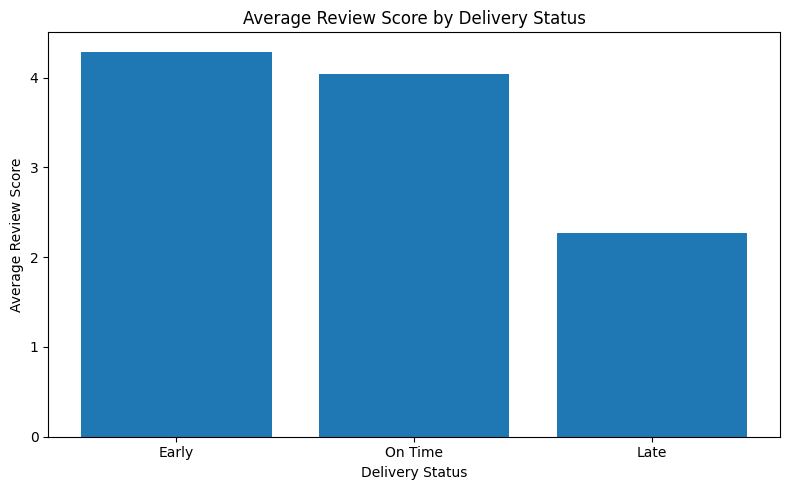

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    delivery_summary["delivery_status"],
    delivery_summary["avg_review_score"]
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.tight_layout()

plt.show()

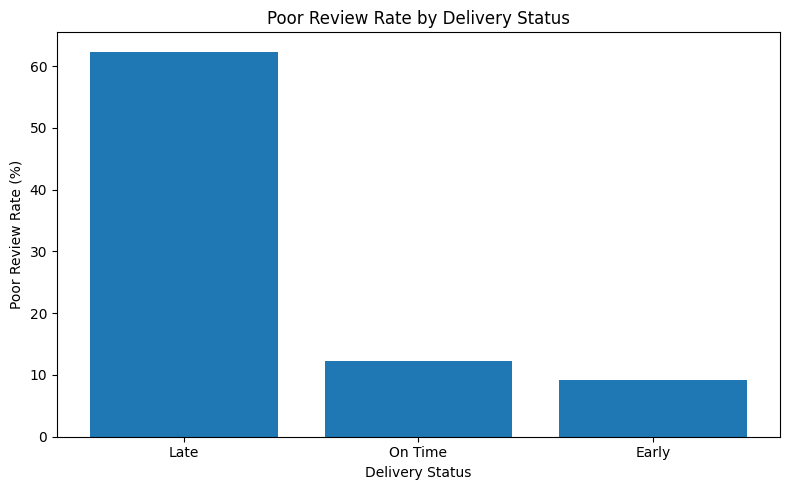

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    poor_review_summary["delivery_status"],
    poor_review_summary["poor_review_rate_pct"]
)

plt.title("Poor Review Rate by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Poor Review Rate (%)")
plt.tight_layout()

plt.show()

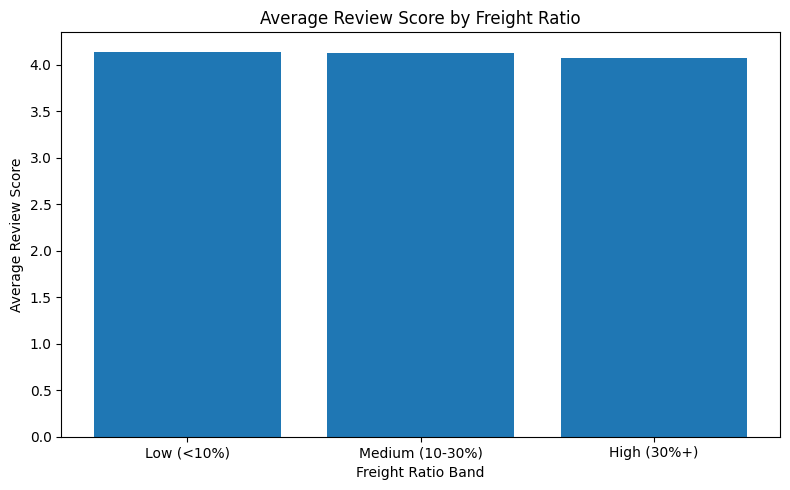

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    freight_summary["freight_band"],
    freight_summary["avg_review_score"]
)

plt.title("Average Review Score by Freight Ratio")
plt.xlabel("Freight Ratio Band")
plt.ylabel("Average Review Score")
plt.tight_layout()

plt.show()

# Task 9 — Repeat-Customer Analysis — Owner: Ibraheem


In [ ]:
# Task 9: تحليل العملاء المتكررين والجدد
query_task_9 = """
WITH customer_order_counts AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
),
customer_segments AS (
    SELECT
        customer_unique_id,
        order_count,
        CASE
            WHEN order_count = 1 THEN 'One-time Customer'
            ELSE 'Repeat Customer'
        END AS customer_type
    FROM customer_order_counts
)
SELECT
    customer_type,
    COUNT(customer_unique_id) AS customer_count,
    ROUND(COUNT(customer_unique_id) * 100.0 / (SELECT COUNT(*) FROM customer_segments), 2) AS percentage_share
FROM customer_segments
GROUP BY customer_type;
"""

df_repeat_customer = pd.read_sql_query(query_task_9, conn)
df_repeat_customer


,customer_type,customer_count,percentage_share
0,One-time Customer,93099,96.88
1,Repeat Customer,2997,3.12


# Task 10 — Freight Efficiency — Owner: leqaa


1. Freight Efficiency by State

In [ ]:
query = """
SELECT
    c.customer_state,
    SUM(oi.price) AS total_item_value,
    SUM(oi.freight_value) AS total_freight,
    SUM(oi.freight_value) * 100.0 / SUM(oi.price) AS freight_ratio
FROM order_items oi
JOIN orders o
    ON oi.order_id = o.order_id
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE oi.price > 0
GROUP BY c.customer_state
ORDER BY freight_ratio DESC;
"""

state_df = pd.read_sql_query(query, conn)
state_df


,customer_state,total_item_value,total_freight,freight_ratio
0,RR,7829.43,2235.19,28.548566
1,MA,119648.22,31523.77,26.347045
2,RO,46140.64,11417.38,24.744737
3,AM,22356.84,5478.89,24.506549
4,PI,86914.08,21218.20,24.412845
5,SE,58920.85,14111.47,23.949875
6,TO,49621.74,11732.68,23.644233
7,AC,15982.95,3686.75,23.066768
8,RN,83034.98,18860.10,22.713440
9,PE,262788.03,59449.66,22.622667


 📊 Freight Efficiency by State

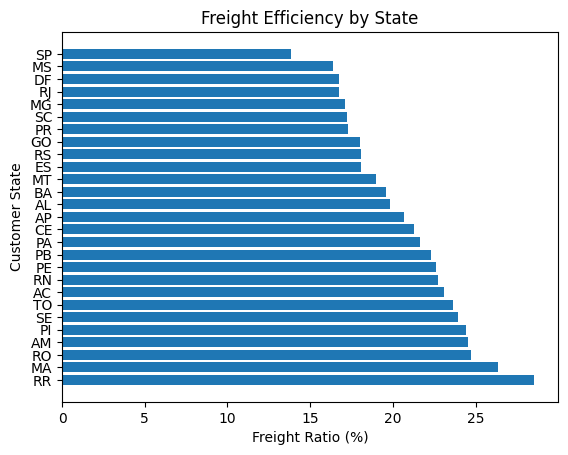

In [ ]:
import matplotlib.pyplot as plt

plt.barh(state_df["customer_state"], state_df["freight_ratio"])

plt.xlabel("Freight Ratio (%)")
plt.ylabel("Customer State")
plt.title("Freight Efficiency by State")

plt.show()


3. Freight Efficiency by Category

In [ ]:
query = """
SELECT
    p.product_category_name,
    SUM(oi.price) AS total_item_value,
    SUM(oi.freight_value) AS total_freight,
    SUM(oi.freight_value) * 100.0 / SUM(oi.price) AS freight_ratio
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
WHERE oi.price > 0
GROUP BY p.product_category_name
ORDER BY freight_ratio DESC;
"""

pd.read_sql_query(query, conn)


,product_category_name,total_item_value,total_freight,freight_ratio
0,casa_conforto_2,760.27,410.31,53.968985
1,flores,1110.04,488.87,44.040755
2,moveis_colchao_e_estofado,4368.08,1630.46,37.326697
3,artigos_de_natal,8800.82,3229.30,36.693172
4,fraldas_higiene,1567.59,573.68,36.596304
...,...,...,...,...
69,agro_industria_e_comercio,72530.47,5843.60,8.056752
70,portateis_cozinha_e_preparadores_de_alimentos,3968.53,309.76,7.805409
71,telefonia_fixa,59583.00,4637.81,7.783781
72,portateis_casa_forno_e_cafe,47445.71,2747.86,5.791588


4. Freight Efficiency by Seller

In [ ]:
query = """
SELECT
    seller_id,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(price) AS total_item_value,
    SUM(freight_value) AS total_freight,
    SUM(freight_value) * 100.0 / SUM(price) AS freight_ratio
FROM order_items
WHERE price > 0
GROUP BY seller_id
HAVING COUNT(DISTINCT order_id) >= 10
ORDER BY freight_ratio DESC;
"""

pd.read_sql_query(query, conn)


,seller_id,total_orders,total_item_value,total_freight,freight_ratio
0,916748bc99315c2d202898ae58b1617e,25,369.40,377.11,102.087168
1,6d988d6174a2c27441597174f8905515,19,371.73,365.47,98.315982
2,179d859f51292aac5c10806a356f7af9,18,404.47,395.80,97.856454
3,5c853bb56f70f4d14218944bae111d7a,23,263.13,251.06,95.412914
4,48efc9d94a9834137efd9ea76b065a38,33,345.60,320.40,92.708333
...,...,...,...,...,...
1266,403aa86912527d730337ffcb0fb096ab,11,8959.89,204.62,2.283733
1267,b839e41795b7f3ad94cc2014a52f6796,33,42829.00,920.93,2.150249
1268,2bf6a2c1e71bbd29a4ad64e6d3c3629f,30,50628.90,1000.59,1.976322
1269,b1b3948701c5c72445495bd161b83a4c,18,24699.19,486.30,1.968890


# Task 11 — Window-Function Ranking — Owner:  Rewan Mousa


In [ ]:
task11 = pd.read_sql_query("""
WITH seller_state_sales AS (

    SELECT
        c.customer_state,
        oi.seller_id,

        SUM(oi.price) AS revenue,

        COUNT(DISTINCT oi.order_id) AS orders

    FROM order_items oi

    JOIN orders o
        ON oi.order_id = o.order_id

    JOIN customers c
        ON o.customer_id = c.customer_id

    GROUP BY
        c.customer_state,
        oi.seller_id

    HAVING COUNT(DISTINCT oi.order_id) >= 50
),

ranked_sellers AS (

    SELECT
        customer_state,
        seller_id,
        revenue,
        orders,

        RANK() OVER (
            PARTITION BY customer_state
            ORDER BY revenue DESC
        ) AS seller_rank

    FROM seller_state_sales
)

SELECT *
FROM ranked_sellers
WHERE seller_rank <= 3

ORDER BY customer_state, seller_rank
""", conn)

task11


,customer_state,seller_id,revenue,orders,seller_rank
0,BA,7c67e1448b00f6e969d365cea6b010ab,10694.36,51,1
1,BA,7a67c85e85bb2ce8582c35f2203ad736,6656.47,52,2
2,BA,6560211a19b47992c3666cc44a7e94c0,5738.00,84,3
3,CE,cc419e0650a3c5ba77189a1882b7556a,3313.48,50,1
4,DF,cc419e0650a3c5ba77189a1882b7556a,4035.40,57,1
5,MG,a1043bafd471dff536d0c462352beb48,26637.12,188,1
6,MG,4a3ca9315b744ce9f8e9374361493884,25789.14,230,2
7,MG,fa1c13f2614d7b5c4749cbc52fecda94,24086.40,67,3
8,PE,6560211a19b47992c3666cc44a7e94c0,4057.00,52,1
9,PR,1025f0e2d44d7041d6cf58b6550e0bfa,11005.99,69,1


# Task 12 — Reusable Analytics View — Owner: Rewan Ebrahem


In [ ]:
create_view_query = """
DROP VIEW IF EXISTS vw_order_summary;

CREATE VIEW vw_order_summary AS

WITH item_per_order AS (
    SELECT
        order_id,
        COUNT(*) AS total_items,
        SUM(price) AS item_revenue,
        SUM(freight_value) AS total_freight
    FROM order_items
    GROUP BY order_id
),

payment_per_order AS (
    SELECT
        order_id,
        SUM(payment_value) AS total_payment,
        MAX(payment_installments) AS max_installments,
        COUNT(*) AS payment_records
    FROM order_payments
    GROUP BY order_id
),

review_per_order AS (
    SELECT
        order_id,
        AVG(review_score) AS avg_review_score,
        COUNT(*) AS review_count
    FROM order_reviews
    GROUP BY order_id
)

SELECT
    o.order_id,
    o.customer_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL
            THEN NULL

        WHEN date(o.order_delivered_customer_date)
             < date(o.order_estimated_delivery_date)
            THEN 'Early'

        WHEN date(o.order_delivered_customer_date)
             = date(o.order_estimated_delivery_date)
            THEN 'On Time'

        ELSE 'Late'
    END AS delivery_status,

    COALESCE(i.total_items, 0) AS total_items,
    COALESCE(i.item_revenue, 0) AS item_revenue,
    COALESCE(i.total_freight, 0) AS total_freight,

    COALESCE(p.total_payment, 0) AS total_payment,
    p.max_installments,
    COALESCE(p.payment_records, 0) AS payment_records,

    r.avg_review_score,
    COALESCE(r.review_count, 0) AS review_count

FROM orders AS o

LEFT JOIN item_per_order AS i
    ON o.order_id = i.order_id

LEFT JOIN payment_per_order AS p
    ON o.order_id = p.order_id

LEFT JOIN review_per_order AS r
    ON o.order_id = r.order_id;
"""

conn.executescript(create_view_query)

print("vw_order_summary created successfully")

vw_order_summary created successfully


In [ ]:
view_preview = pd.read_sql_query(
    """
    SELECT *
    FROM vw_order_summary
    LIMIT 10;
    """,
    conn
)

display(view_preview)

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_status,total_items,item_revenue,total_freight,total_payment,max_installments,payment_records,avg_review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,Early,1,29.99,8.72,38.71,1,3,4.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,Early,1,118.70,22.76,141.46,1,1,4.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,Early,1,159.90,19.22,179.12,3,1,5.0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,Early,1,45.00,27.20,72.20,1,1,5.0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,Early,1,19.90,8.72,28.62,1,1,5.0,1
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-26 10:57:55,2017-08-01 00:00:00,Early,1,147.90,27.36,175.26,6,1,4.0,1
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,None,2017-05-09 00:00:00,None,1,49.90,16.05,65.95,1,1,2.0,1
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-26 12:55:51,2017-06-07 00:00:00,Early,1,59.99,15.17,75.16,3,1,5.0,1
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-02-02 14:08:10,2017-03-06 00:00:00,Early,1,19.90,16.05,35.95,1,1,1.0,1
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-08-16 17:14:30,2017-08-23 00:00:00,Early,1,149.99,19.77,169.76,1,2,5.0,1


In [ ]:
view_validation = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT order_id) AS distinct_orders,
        COUNT(*) - COUNT(DISTINCT order_id) AS duplicate_orders
    FROM vw_order_summary;
    """,
    conn
)

display(view_validation)

,total_rows,distinct_orders,duplicate_orders
0,99441,99441,0


In [ ]:
count_check = pd.read_sql_query(
    """
    SELECT
        (SELECT COUNT(*) FROM orders) AS orders_table_count,
        (SELECT COUNT(*) FROM vw_order_summary) AS view_count;
    """,
    conn
)

display(count_check)

,orders_table_count,view_count
0,99441,99441


In [ ]:
summary_check = pd.read_sql_query(
    """
    SELECT
        delivery_status,
        COUNT(*) AS total_orders,
        ROUND(AVG(total_payment), 2) AS avg_payment,
        ROUND(AVG(avg_review_score), 2) AS avg_review_score
    FROM vw_order_summary
    WHERE delivery_status IS NOT NULL
    GROUP BY delivery_status;
    """,
    conn
)

display(summary_check)

,delivery_status,total_orders,avg_payment,avg_review_score
0,Early,88649,158.72,4.29
1,Late,6535,176.11,2.27
2,On Time,1292,155.40,4.04
